# Đánh giá mức độ ổn định doanh thu của từng danh mục sản phẩm

## 1. Khởi tạo và Thiết lập Môi trường

In [4]:
# Import các thư viện cần thiết cho phân tích dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Bỏ qua các cảnh báo không quan trọng
warnings.filterwarnings('ignore')

# Thiết lập kích thước mặc định cho các biểu đồ
plt.rcParams['figure.figsize'] = (16, 12)
# Thiết lập kiểu dáng cho các biểu đồ sử dụng Seaborn
sns.set_style("whitegrid")

# In tiêu đề chính cho báo cáo phân tích
print('\n' + '='*100)
print('DANH GIA MUC DO ON DINH DOANH THU CUA TUNG DANH MUC SAN PHAM')
print('='*100)


DANH GIA MUC DO ON DINH DOANH THU CUA TUNG DANH MUC SAN PHAM


## 2. Tải và Chuẩn bị Dữ liệu

In [6]:
# In thông báo đang tải dữ liệu và đọc các file CSV vào DataFrame
print('\nDang tai du lieu...')
orders_df = pd.read_csv('/content/ORDERS (1).csv')
order_items_df = pd.read_csv('/content/ORDER_ITEM (2).csv')
products_df = pd.read_csv('/content/product (1).csv')


Dang tai du lieu...


In [7]:
# Xử lý cột ngày tháng: Chuyển đổi 'order_date' sang định dạng datetime
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
# Trích xuất 'năm_tháng' từ 'order_date' để nhóm dữ liệu hàng tháng
orders_df['year_month'] = orders_df['order_date'].dt.to_period('M')

# Hợp nhất dữ liệu giữa order_items_df và orders_df dựa trên 'order_id'
# Chỉ chọn các cột cần thiết từ orders_df để tránh trùng lặp dữ liệu
data = order_items_df.merge(orders_df[['order_id', 'order_date', 'year_month', 'order_status']], on='order_id')
# Tiếp tục hợp nhất dữ liệu với products_df để lấy thông tin 'category' (danh mục sản phẩm)
data = data.merge(products_df[['product_id', 'category']], on='product_id')

# Tính toán doanh thu: (số lượng * đơn giá) - số tiền giảm giá
data['revenue'] = (data['quantity'] * data['unit_price']) - data['discount_amount']

# Lọc dữ liệu: Chỉ giữ lại các đơn hàng có trạng thái 'delivered' (đã giao thành công)
data = data[data['order_status'] == 'delivered'].copy()

# In ra các thông tin tổng quan về dữ liệu đã xử lý để kiểm tra
print(f"Tổng số dòng dữ liệu: {len(data):,}")
print(f"Tổng doanh thu: ${data['revenue'].sum():,.0f}")
print(f"Khoảng thời gian: {orders_df['order_date'].min().date()} đến {orders_df['order_date'].max().date()}")
print(f"Số danh mục: {data['category'].nunique()}")

Tổng số dòng dữ liệu: 570,887
Tổng doanh thu: $12,518,175,957
Khoảng thời gian: 2012-07-04 đến 2022-12-31
Số danh mục: 4


## 3. Tổng hợp Doanh thu theo Tháng và Danh mục

In [8]:
# Nhóm dữ liệu theo 'category' (danh mục) và 'year_month' (năm_tháng), sau đó tính tổng doanh thu
monthly = data.groupby(['category', 'year_month'])['revenue'].sum().reset_index()
# Chuyển đổi dữ liệu từ định dạng dài sang rộng (pivot) để dễ dàng phân tích doanh thu của từng danh mục qua các tháng
pivot = monthly.pivot(index='year_month', columns='category', values='revenue').fillna(0)

# In số lượng tháng được bao gồm trong phân tích
print(f"Số tháng phân tích: {len(pivot)}")

Số tháng phân tích: 126


## 4. Định nghĩa các Hàm hỗ trợ Tính toán và Phân loại

In [9]:
def tinh_xu_huong(series):
    # Hàm tính toán xu hướng (trend) của một chuỗi thời gian (doanh thu)
    x = np.arange(len(series)) # Tạo mảng chỉ số x cho chuỗi
    y = series.values # Lấy giá trị doanh thu y
    if len(x) > 1:
        # Sử dụng hồi quy tuyến tính để tìm hệ số góc (slope) làm chỉ số xu hướng
        return np.polyfit(x, y, 1)[0]
    return 0 # Trả về 0 nếu chuỗi quá ngắn để tính toán

def tinh_tang_truong(series):
    # Hàm tính toán tỷ lệ tăng trưởng trung bình hàng tháng
    ty_le = series.pct_change().dropna() # Tính tỷ lệ thay đổi phần trăm và loại bỏ giá trị NaN đầu tiên
    return ty_le.mean() if len(ty_le) > 0 else 0 # Trả về giá trị trung bình nếu có dữ liệu, ngược lại là 0

In [10]:
def phan_loai_on_dinh(row):
    # Phân loại độ ổn định doanh thu dựa trên 'HesoSinhDong' (Hệ số biến thiên)
    heso = row['HesoSinhDong']
    if heso < 0.20:
        return 'On_Dinh' # Doanh thu rất ổn định
    elif heso < 0.40:
        return 'Vua_Phai' # Doanh thu có mức độ ổn định trung bình
    else:
        return 'Bien_Dong_Manh' # Doanh thu biến động mạnh

def phan_loai_xu_huong(row):
    # Phân loại xu hướng doanh thu dựa trên 'XuHuongTang' và 'TyLeTangTruongThang'
    xu_huong = row['XuHuongTang']
    tang_truong = row['TyLeTangTruongThang']
    if xu_huong > 0 and tang_truong > 0.01:
        return 'Tang_Truong' # Có xu hướng tăng trưởng rõ rệt
    elif xu_huong < -100 or tang_truong < -0.01:
        return 'Suy_Giam' # Có xu hướng suy giảm đáng kể
    else:
        return 'On_Dinh' # Ổn định hoặc không có xu hướng rõ ràng

def xac_dinh_uu_tien(row):
    # Xác định mức độ ưu tiên đầu tư dựa trên sự kết hợp của nhiều yếu tố
    heso = row['HesoSinhDong']
    xu_huong = row['PhanLoaiXuHuong']
    doanh_thu = row['TongDoanhdoThu']
    median = result['TongDoanhdoThu'].median() # Tính toán median để so sánh

    if heso < 0.40 and xu_huong == 'Tang_Truong':
        return 'Muc1_Cao_Tang_On_Dinh' # Ưu tiên cao nhất: tăng trưởng và ổn định
    elif heso < 0.60 and xu_huong == 'Tang_Truong':
        return 'Muc2_Cao_Tang_Bien_Dong' # Ưu tiên cao: tăng trưởng nhưng có biến động
    elif heso < 0.40 and doanh_thu > median:
        return 'Muc3_Trung_On_Dinh' # Ưu tiên trung bình: ổn định và doanh thu trên trung bình
    elif heso < 0.40 and xu_huong == 'Suy_Giam':
        return 'Muc4_Trung_Suy_Giam' # Ưu tiên trung bình: ổn định nhưng đang suy giảm
    elif heso >= 0.40:
        return 'Muc5_Thap_Bien_Dong' # Ưu tiên thấp: biến động mạnh
    else:
        return 'Muc6_Thap_Monitor' # Cần theo dõi thêm để đưa ra quyết định

## 5. Tính toán các Chỉ số Phân tích và Phân loại

In [11]:
print('\nTính toán các chỉ số...')

# Tạo DataFrame 'result' để lưu trữ các chỉ số phân tích, với index là tên các danh mục
result = pd.DataFrame(index=pivot.columns)
result.index.name = 'TenDanhMuc'

# MEASURE - Các chỉ số đo lường trực tiếp từ dữ liệu doanh thu
result['TongDoanhdoThu'] = pivot.sum() # Tổng doanh thu của mỗi danh mục trong toàn bộ thời gian
result['DoanhdoThuThangTB'] = pivot.mean() # Doanh thu trung bình hàng tháng của mỗi danh mục
result['DoanhdoThuMin'] = pivot.min() # Doanh thu thấp nhất của mỗi danh mục trong một tháng bất kỳ
result['DoanhdoThuMax'] = pivot.max() # Doanh thu cao nhất của mỗi danh mục trong một tháng bất kỳ

# METRIC - Các chỉ số được tính toán để đánh giá biến động và xu hướng
result['Variance'] = pivot.var() # Phương sai của doanh thu hàng tháng
result['DoLechChuan'] = pivot.std() # Độ lệch chuẩn của doanh thu hàng tháng
result['HesoSinhDong'] = result['DoLechChuan'] / result['DoanhdoThuThangTB'] # Hệ số biến thiên (Coefficient of Variation) - đo lường độ ổn định

# Áp dụng các hàm 'tinh_xu_huong' và 'tinh_tang_truong' đã định nghĩa
result['XuHuongTang'] = pivot.apply(tinh_xu_huong, axis=0) # Chỉ số xu hướng tăng trưởng tuyến tính
result['TyLeTangTruongThang'] = pivot.apply(tinh_tang_truong, axis=0) # Tỷ lệ tăng trưởng trung bình hàng tháng

# KPI - Các chỉ số hiệu suất chính khác
result['PhambViDoanhdoThu'] = result['DoanhdoThuMax'] - result['DoanhdoThuMin'] # Phạm vi biến động doanh thu (Max - Min)
result['ChisoSinhDong'] = result['PhambViDoanhdoThu'] / result['DoanhdoThuThangTB'] # Chỉ số biến động dựa trên phạm vi và trung bình

# Áp dụng các hàm phân loại đã định nghĩa để gán nhãn cho mỗi danh mục
result['PhanLoaiOnDinh'] = result.apply(phan_loai_on_dinh, axis=1) # Phân loại độ ổn định
result['PhanLoaiXuHuong'] = result.apply(phan_loai_xu_huong, axis=1) # Phân loại xu hướng
result['PhanLoaiChung'] = result['PhanLoaiOnDinh'] + ' | ' + result['PhanLoaiXuHuong'] # Phân loại tổng hợp

# Xác định mức độ ưu tiên đầu tư cho mỗi danh mục
result['UuTienDauTu'] = result.apply(xac_dinh_uu_tien, axis=1)
# Sắp xếp kết quả theo 'HesoSinhDong' để dễ dàng nhận biết các danh mục ổn định nhất/biến động nhất
result = result.sort_values('HesoSinhDong')


Tính toán các chỉ số...


## 6. Hiển thị Kết quả Phân tích

In [12]:
# In tiêu đề cho phần hiển thị kết quả phân tích
print('\n' + '='*100)
print('KET QUA PHAN TICH')
print('='*100)

# Tạo bản sao của DataFrame 'result' để định dạng hiển thị mà không ảnh hưởng đến dữ liệu gốc
hien_thi = result.copy()
# Định dạng các cột liên quan đến tiền tệ và số lượng lớn với dấu phân cách hàng nghìn
for col in ['TongDoanhdoThu', 'DoanhdoThuThangTB', 'DoanhdoThuMin', 'DoanhdoThuMax', 'PhambViDoanhdoThu', 'Variance', 'DoLechChuan']:
    hien_thi[col] = hien_thi[col].apply(lambda x: f"{x:,.0f}")

# Định dạng các cột hệ số (tỷ lệ) với 4 chữ số thập phân
for col in ['HesoSinhDong', 'TyLeTangTruongThang', 'ChisoSinhDong']:
    hien_thi[col] = hien_thi[col].apply(lambda x: f"{x:.4f}")

# Định dạng cột 'XuHuongTang' với dấu phân cách hàng nghìn
hien_thi['XuHuongTang'] = hien_thi['XuHuongTang'].apply(lambda x: f"{x:,.0f}")

# Xác định các cột chính cần hiển thị trong bảng kết quả
cac_cot_chinh = ['TongDoanhdoThu', 'DoanhdoThuThangTB', 'HesoSinhDong',
                 'TyLeTangTruongThang', 'PhanLoaiOnDinh', 'PhanLoaiXuHuong',
                 'PhanLoaiChung', 'UuTienDauTu']

# In bảng kết quả chính đã định dạng ra màn hình
print('\n' + hien_thi[cac_cot_chinh].to_string())


KET QUA PHAN TICH

            TongDoanhdoThu DoanhdoThuThangTB HesoSinhDong TyLeTangTruongThang  PhanLoaiOnDinh PhanLoaiXuHuong                 PhanLoaiChung              UuTienDauTu
TenDanhMuc                                                                                                                                                          
Outdoor      1,875,828,887        14,887,531       0.4871              0.0355  Bien_Dong_Manh        Suy_Giam     Bien_Dong_Manh | Suy_Giam      Muc5_Thap_Bien_Dong
Streetwear  10,030,049,480        79,603,567       0.5064              0.0405  Bien_Dong_Manh        Suy_Giam     Bien_Dong_Manh | Suy_Giam      Muc5_Thap_Bien_Dong
Casual         349,094,264         2,770,589       0.5302              0.0620  Bien_Dong_Manh     Tang_Truong  Bien_Dong_Manh | Tang_Truong  Muc2_Cao_Tang_Bien_Dong
GenZ           263,203,327         2,088,915       0.7285              0.0866  Bien_Dong_Manh        Suy_Giam     Bien_Dong_Manh | Suy_Giam      Muc5_Thap_

## 7. Phân loại và Đánh giá Danh mục

In [13]:
# In tiêu đề cho phần phân loại danh mục
print('\n' + '='*100)
print('PHAN LOAI DANH MUC THEO YEU CAU')
print('='*100)

# 1. Danh mục có doanh thu ổn định
print('\n1. DANH MUC CO DOANH THU ON DINH:')
on_dinh = result[result['PhanLoaiOnDinh'] == 'On_Dinh'].index.tolist()
if on_dinh:
    for cat in on_dinh:
        print(f"   - {cat}: Hệ số sinh động={result.loc[cat, 'HesoSinhDong']:.4f}, Tăng trưởng={result.loc[cat, 'TyLeTangTruongThang']:.2%}")
else:
    print("   Không có danh mục nào ổn định.")

# 2. Danh mục có doanh thu tăng trưởng
print('\n2. DANH MUC CO DOANH THU TANG TRUONG:')
tang_truong = result[result['PhanLoaiXuHuong'] == 'Tang_Truong'].index.tolist()
if tang_truong:
    for cat in tang_truong:
        print(f"   - {cat}: Xu hướng={result.loc[cat, 'XuHuongTang']:,.0f}, Tăng trưởng={result.loc[cat, 'TyLeTangTruongThang']:.2%}")
else:
    print("   Không có danh mục nào tăng trưởng.")

# 3. Danh mục có doanh thu biến động mạnh
print('\n3. DANH MUC CO DOANH THU BIEN DONG MANH:')
bien_dong = result[result['PhanLoaiOnDinh'] == 'Bien_Dong_Manh'].index.tolist()
if bien_dong:
    for cat in bien_dong:
        print(f"   - {cat}: Hệ số sinh động={result.loc[cat, 'HesoSinhDong']:.4f}, Phạm vi={result.loc[cat, 'PhambViDoanhdoThu']:,.0f}")
else:
    print("   Không có danh mục nào biến động mạnh.")

# 4. Danh mục có doanh thu suy giảm
print('\n4. DANH MUC CO DOANH THU SUY GIAM:')
suy_giam = result[result['PhanLoaiXuHuong'] == 'Suy_Giam'].index.tolist()
if suy_giam:
    for cat in suy_giam:
        print(f"   - {cat}: Xu hướng={result.loc[cat, 'XuHuongTang']:,.0f}, Tăng trưởng={result.loc[cat, 'TyLeTangTruongThang']:.2%}")
else:
    print("   Không có danh mục nào suy giảm.")


PHAN LOAI DANH MUC THEO YEU CAU

1. DANH MUC CO DOANH THU ON DINH:
   Không có danh mục nào ổn định.

2. DANH MUC CO DOANH THU TANG TRUONG:
   - Casual: Xu hướng=10,061, Tăng trưởng=6.20%

3. DANH MUC CO DOANH THU BIEN DONG MANH:
   - Outdoor: Hệ số sinh động=0.4871, Phạm vi=31,665,568
   - Streetwear: Hệ số sinh động=0.5064, Phạm vi=161,014,171
   - Casual: Hệ số sinh động=0.5302, Phạm vi=8,589,332
   - GenZ: Hệ số sinh động=0.7285, Phạm vi=10,876,619

4. DANH MUC CO DOANH THU SUY GIAM:
   - Outdoor: Xu hướng=-165,807, Tăng trưởng=3.55%
   - Streetwear: Xu hướng=-369,610, Tăng trưởng=4.05%
   - GenZ: Xu hướng=-1,590, Tăng trưởng=8.66%


## 8. Xuất Kết quả Phân tích ra File CSV

In [14]:
# In tiêu đề cho phần xuất file kết quả
print('\n' + '='*100)
print('XUAT FILE KET QUA')
print('='*100)

# Tạo bản sao của DataFrame 'result' để định dạng cho việc xuất file
xuat_result = result.copy()
# Định dạng các cột tiền tệ và số lượng lớn thành chuỗi số nguyên để xuất ra CSV
for col in ['TongDoanhdoThu', 'DoanhdoThuThangTB', 'DoanhdoThuMin', 'DoanhdoThuMax',
            'PhambViDoanhdoThu', 'Variance', 'DoLechChuan']:
    xuat_result[col] = xuat_result[col].apply(lambda x: f"{x:.0f}")

# Định dạng các cột hệ số (tỷ lệ) thành chuỗi với 4 chữ số thập phân
for col in ['HesoSinhDong', 'TyLeTangTruongThang', 'ChisoSinhDong']:
    xuat_result[col] = xuat_result[col].apply(lambda x: f"{x:.4f}")

# Định dạng cột 'XuHuongTang' thành chuỗi số nguyên
xuat_result['XuHuongTang'] = xuat_result['XuHuongTang'].apply(lambda x: f"{x:.0f}")

# Xuất file CSV chứa toàn bộ 14 chỉ số phân tích chi tiết
xuat_result.to_csv('Phan_Tich_On_Dinh_Doanh_Thu_Chi_Tiet.csv', index=True)
print("\nFile: Phan_Tich_On_Dinh_Doanh_Thu_Chi_Tiet.csv")
print("Nội dung: Toàn bộ 14 chỉ số phân tích")

# Xuất file CSV chứa doanh thu của từng danh mục qua từng tháng
pivot.to_csv('Theo_Doi_Doanh_Thu_Theo_Thang.csv', index=True)
print("File: Theo_Doi_Doanh_Thu_Theo_Thang.csv")
print("Nội dung: Doanh thu của từng danh mục qua từng tháng")

# Chọn lọc các cột quan trọng để tạo file CSV tóm tắt phân loại và ưu tiên đầu tư
phan_loai_tom_tat = result[['TongDoanhdoThu', 'HesoSinhDong', 'TyLeTangTruongThang',
                             'PhanLoaiOnDinh', 'PhanLoaiXuHuong',
                             'UuTienDauTu']].copy()
phan_loai_tom_tat.to_csv('Phan_Loai_Danh_Muc_On_Dinh.csv', index=True)
print("File: Phan_Loai_Danh_Muc_On_Dinh.csv")
print("Nội dung: Phân loại và ưu tiên đầu tư để cải thiện chiến lược")


XUAT FILE KET QUA

File: Phan_Tich_On_Dinh_Doanh_Thu_Chi_Tiet.csv
Nội dung: Toàn bộ 14 chỉ số phân tích
File: Theo_Doi_Doanh_Thu_Theo_Thang.csv
Nội dung: Doanh thu của từng danh mục qua từng tháng
File: Phan_Loai_Danh_Muc_On_Dinh.csv
Nội dung: Phân loại và ưu tiên đầu tư để cải thiện chiến lược


## 9. Trực quan hóa Dữ liệu (Biểu đồ)

File: Bieu_Do_Phan_Tich_On_Dinh_Doanh_Thu.png
Nội dung: 4 biểu đồ - Theo dõi, Hệ số sinh động, Tổng doanh thu, Phân loại


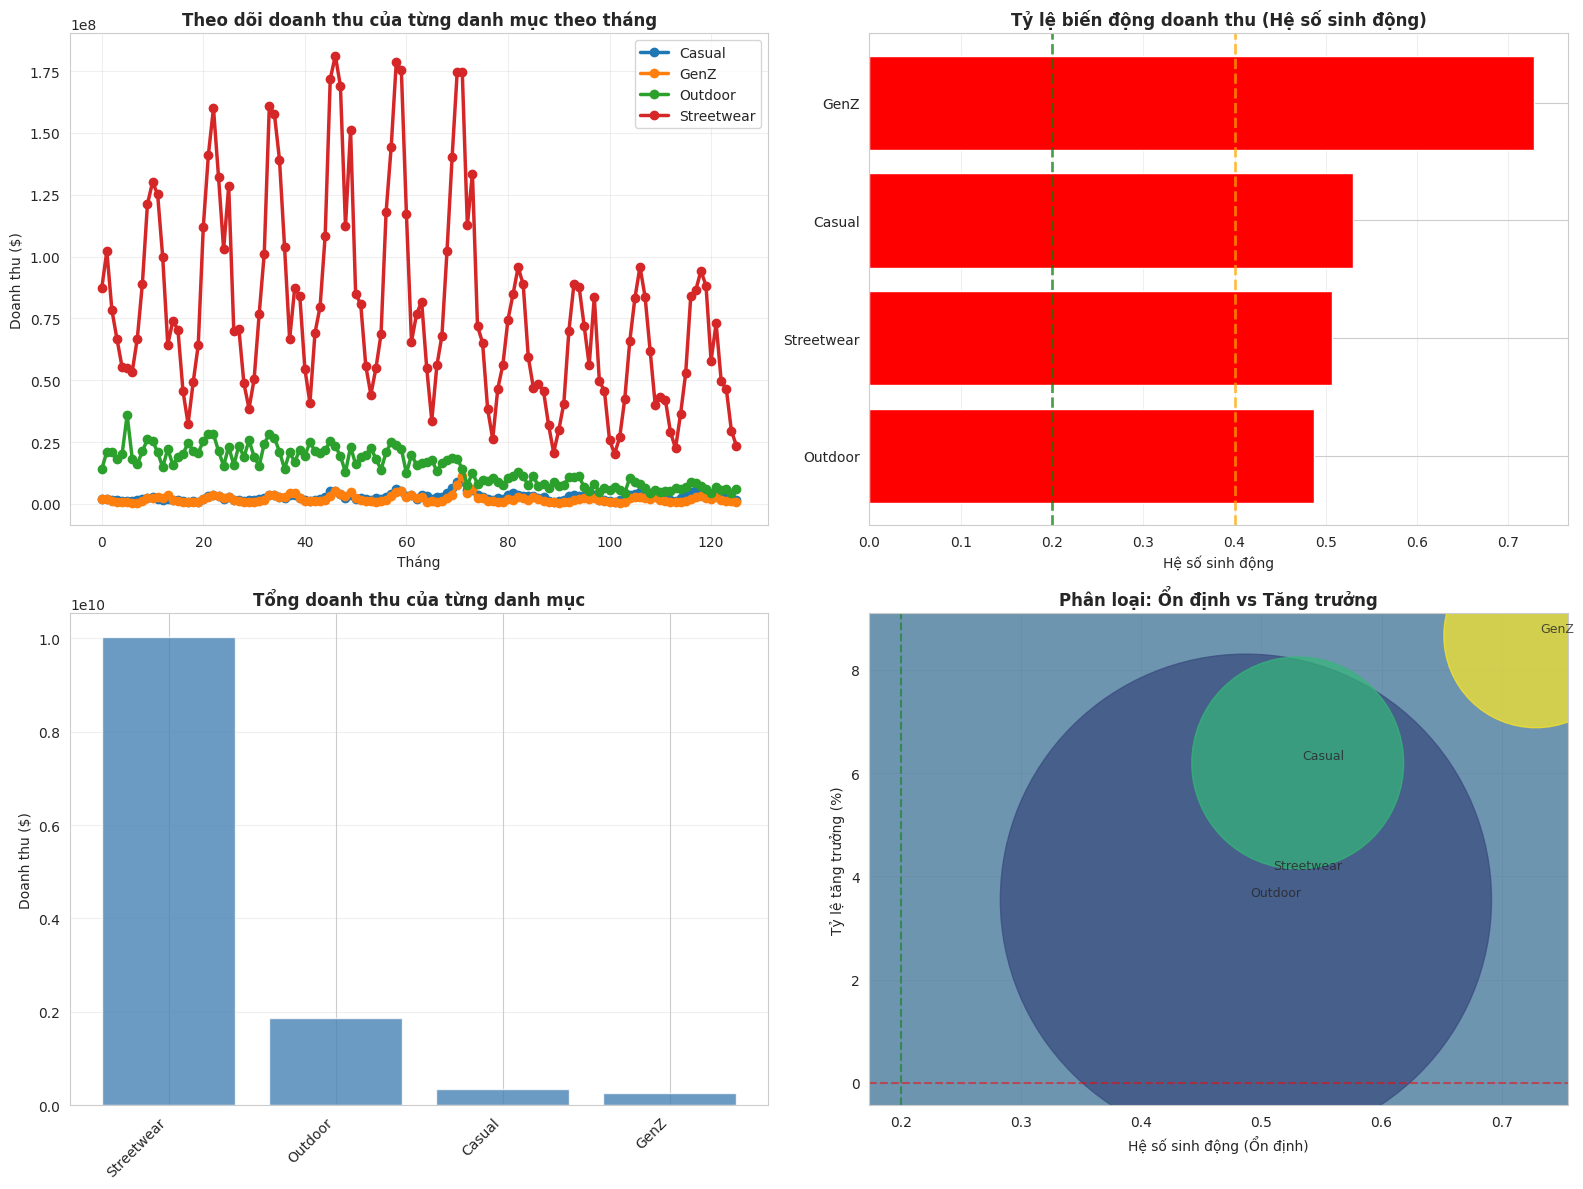

In [15]:
# Khởi tạo một figure (hình) và 4 subplot (biểu đồ con) để hiển thị các biểu đồ phân tích
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 2 hàng, 2 cột, kích thước 16x12 inches

# Biểu đồ 1: Theo dõi doanh thu của từng danh mục theo tháng (Line plot)
ax = axes[0, 0]
for col in pivot.columns:
    ax.plot(range(len(pivot)), pivot[col].values, marker='o', label=col, linewidth=2.5)
ax.set_title('Theo dõi doanh thu của từng danh mục theo tháng', fontweight='bold', fontsize=12)
ax.set_xlabel('Tháng')
ax.set_ylabel('Doanh thu ($)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Biểu đồ 2: Tỷ lệ biến động doanh thu (Hệ số sinh động) (Horizontal Bar chart)
ax = axes[0, 1]
heso_sorted = result['HesoSinhDong'].sort_values() # Sắp xếp danh mục theo hệ số sinh động
colors = ['green' if x < 0.20 else 'orange' if x < 0.40 else 'red' for x in heso_sorted.values] # Gán màu sắc dựa trên mức độ ổn định
ax.barh(range(len(heso_sorted)), heso_sorted.values, color=colors)
ax.set_yticks(range(len(heso_sorted)))
ax.set_yticklabels(heso_sorted.index)
ax.set_title('Tỷ lệ biến động doanh thu (Hệ số sinh động)', fontweight='bold', fontsize=12)
ax.set_xlabel('Hệ số sinh động')
ax.axvline(x=0.20, color='green', linestyle='--', alpha=0.7, linewidth=2) # Đường tham chiếu mức ổn định cao
ax.axvline(x=0.40, color='orange', linestyle='--', alpha=0.7, linewidth=2) # Đường tham chiếu mức ổn định trung bình
ax.grid(True, alpha=0.3, axis='x')

# Biểu đồ 3: Tổng doanh thu của từng danh mục (Vertical Bar chart)
ax = axes[1, 0]
tong_dt_sorted = result['TongDoanhdoThu'].sort_values(ascending=False) # Sắp xếp danh mục theo tổng doanh thu giảm dần
ax.bar(range(len(tong_dt_sorted)), tong_dt_sorted.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(tong_dt_sorted)))
ax.set_xticklabels(tong_dt_sorted.index, rotation=45, ha='right') # Đặt nhãn trục x và xoay 45 độ
ax.set_title('Tổng doanh thu của từng danh mục', fontweight='bold', fontsize=12)
ax.set_ylabel('Doanh thu ($)')
ax.grid(True, alpha=0.3, axis='y')

# Biểu đồ 4: Phân loại: Ổn định vs Tăng trưởng (Scatter plot)
ax = axes[1, 1]
# Kích thước điểm trên biểu đồ scatter tỷ lệ với 'TongDoanhdoThu'
scatter = ax.scatter(result['HesoSinhDong'], result['TyLeTangTruongThang']*100,
                     s=result['TongDoanhdoThu']/15000, alpha=0.7, c=range(len(result)), cmap='viridis')
# Ghi chú tên danh mục bên cạnh các điểm trên biểu đồ
for idx, row in result.iterrows():
    ax.annotate(idx, (row['HesoSinhDong'], row['TyLeTangTruongThang']*100),
                fontsize=9, alpha=0.8, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Hệ số sinh động (Ổn định)')
ax.set_ylabel('Tỷ lệ tăng trưởng (%)')
ax.set_title('Phân loại: Ổn định vs Tăng trưởng', fontweight='bold', fontsize=12)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5) # Đường tham chiếu cho tỷ lệ tăng trưởng 0%
ax.axvline(x=0.20, color='green', linestyle='--', alpha=0.5) # Đường tham chiếu cho hệ số sinh động 0.20
ax.grid(True, alpha=0.3)

plt.tight_layout() # Điều chỉnh bố cục để tránh các thành phần biểu đồ bị chồng chéo
plt.savefig('Bieu_Do_Phan_Tich_On_Dinh_Doanh_Thu.png', dpi=300, bbox_inches='tight') # Lưu biểu đồ đã tạo ra file PNG
print("File: Bieu_Do_Phan_Tich_On_Dinh_Doanh_Thu.png")
print("Nội dung: 4 biểu đồ - Theo dõi, Hệ số sinh động, Tổng doanh thu, Phân loại")

## 10. Thống kê Tổng hợp và Đề xuất

In [16]:
# In tiêu đề cho phần thống kê tổng hợp
print('\n' + '='*100)
print('THONG KE TONG HOP')
print('='*100)

# In tổng doanh thu của tất cả các danh mục
print(f"\nTổng doanh thu tất cả danh mục: ${result['TongDoanhdoThu'].sum():,.0f}")
# In danh mục ổn định nhất (có hệ số sinh động thấp nhất)
print(f"Danh mục ổn định nhất (Hệ số sinh động thấp nhất): {result['HesoSinhDong'].idxmin()} (Hệ số={result['HesoSinhDong'].min():.4f})")
# In danh mục biến động nhất (có hệ số sinh động cao nhất)
print(f"Danh mục biến động nhất (Hệ số sinh động cao nhất): {result['HesoSinhDong'].idxmax()} (Hệ số={result['HesoSinhDong'].max():.4f})")
# In danh mục có tỷ lệ tăng trưởng nhanh nhất
print(f"Danh mục tăng trưởng nhanh nhất: {result['TyLeTangTruongThang'].idxmax()} ({result['TyLeTangTruongThang'].max():.2%}/tháng)")
# In danh mục có tỷ lệ suy giảm nhanh nhất
print(f"Danh mục suy giảm nhanh nhất: {result['TyLeTangTruongThang'].idxmin()} ({result['TyLeTangTruongThang'].min():.2%}/tháng)")

# In ra các đề xuất ưu tiên đầu tư dựa trên phân loại đã thực hiện
print("\nXác định danh mục cần ưu tiên đầu tư hoặc cải thiện chiến lược bán hàng:")
for uu_tien in sorted(result['UuTienDauTu'].unique()):
    cats = result[result['UuTienDauTu'] == uu_tien].index.tolist()
    if cats:
        print(f"\n{uu_tien}:")
        for cat in cats:
            print(f"   - {cat}: Doanh thu=${result.loc[cat, 'TongDoanhdoThu']:,.0f}, Hệ số sinh động={result.loc[cat, 'HesoSinhDong']:.4f}")


THONG KE TONG HOP

Tổng doanh thu tất cả danh mục: $12,518,175,957
Danh mục ổn định nhất (Hệ số sinh động thấp nhất): Outdoor (Hệ số=0.4871)
Danh mục biến động nhất (Hệ số sinh động cao nhất): GenZ (Hệ số=0.7285)
Danh mục tăng trưởng nhanh nhất: GenZ (8.66%/tháng)
Danh mục suy giảm nhanh nhất: Outdoor (3.55%/tháng)

Xác định danh mục cần ưu tiên đầu tư hoặc cải thiện chiến lược bán hàng:

Muc2_Cao_Tang_Bien_Dong:
   - Casual: Doanh thu=$349,094,264, Hệ số sinh động=0.5302

Muc5_Thap_Bien_Dong:
   - Outdoor: Doanh thu=$1,875,828,887, Hệ số sinh động=0.4871
   - Streetwear: Doanh thu=$10,030,049,480, Hệ số sinh động=0.5064
   - GenZ: Doanh thu=$263,203,327, Hệ số sinh động=0.7285


## 11. Hoàn thành Phân tích

In [17]:
# In thông báo hoàn thành toàn bộ quá trình phân tích
print('\n' + '='*100)
print('HOÀN THÀNH PHÂN TÍCH')
print('='*100)


HOÀN THÀNH PHÂN TÍCH
